# **Inter-individual Variability in Hemodynamic Responses to Repeated Valsalva Maneuvers**

## **DATA ANALYSIS PROJECT**

The data used in this project is from a publicly available Repository hosted by PhysioNet Goldberger A, Amaral L, Glass L, Hausdorff J, Ivanov PC, Mark R, Mietus JE, Moody GB, Peng CK, Stanley HE. PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220. RRID:SCR_007345.

The dataset was produced under the study: Computational model-based assessment of baroreflex function from response to Valsalva maneuver.
Authors: Samuel A. Kosinski, Brian E. Carlson, Scott L. Hummel, Robert D. Brook, and Daniel A. Beard


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 44.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
✅ Setup complete
2026-04-10 10:08:49 (79.4 MB/s) - ‘rvmh1_data/physionet.org/files/rvmh1/1.0.0/norm027_P.hea’ saved [181/181]

FINISHED --2026-04-10 10:08:49--
Total wall clock time: 46s
Downloaded: 113 files, 6.0

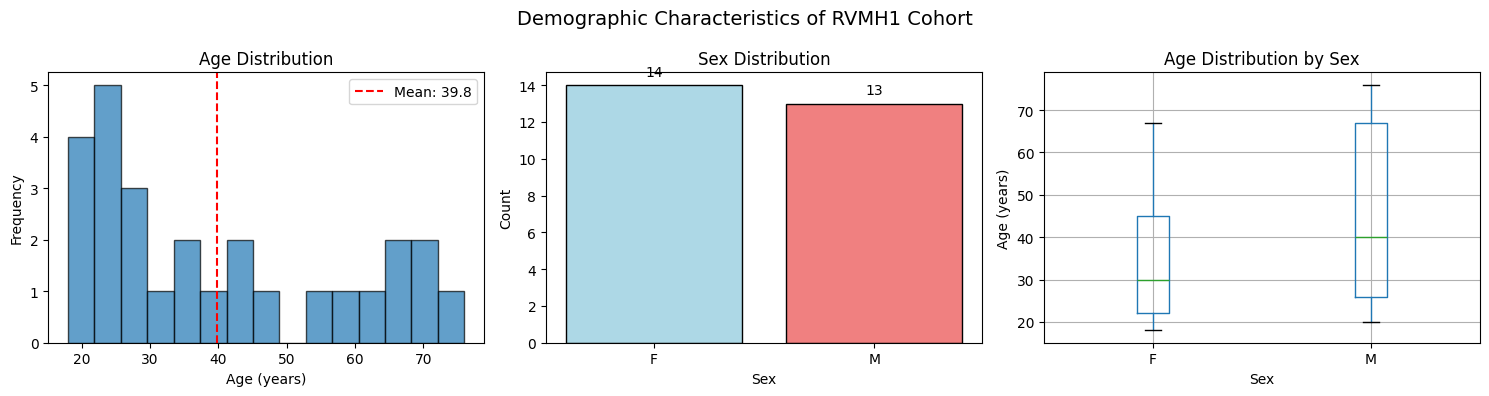


Age statistics:
  Range: 18 - 76 years
  Mean ± SD: 39.8 ± 19.2 years
  Median: 35.0 years


In [1]:
# %% [markdown]
# # Setup and Initial Data Loading
# # Goal: Verify data integrity and understand file structure

# %% [code]
# Install minimal required packages
!pip install wfdb -q

# Import basic libraries
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style for exploration
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Setup complete")

# %% [code]
# Download dataset (only once)
!wget -r -N -c -np --no-check-certificate https://physionet.org/files/rvmh1/1.0.0/ -P rvmh1_data/ 2>&1 | tail -5

print("\n✅ Download attempted")

# %% [code]
# List downloaded files
!ls -la rvmh1_data/physionet.org/files/rvmh1/1.0.0/ | head -20

# %% [code]
# Load and examine demographics
demographics = pd.read_csv('rvmh1_data/physionet.org/files/rvmh1/1.0.0/demographics.csv')
print("DEMOGRAPHICS SUMMARY")
print("="*50)
print(f"Total subjects: {len(demographics)}")
print(f"\nColumns: {demographics.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(demographics.head())
print(f"\nData types:")
print(demographics.dtypes)
print(f"\nMissing values:")
print(demographics.isnull().sum())

# Create subject_id column for easier merging
demographics['subject_id'] = demographics['subject'].apply(lambda x: f"norm{x:03d}")
print(f"\nAdded subject_id column (e.g., {demographics['subject_id'].iloc[0]})")

# %% [code]
# Explore demographics distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution
axes[0].hist(demographics['age'], bins=15, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age Distribution')
axes[0].axvline(demographics['age'].mean(), color='red', linestyle='--',
                label=f'Mean: {demographics["age"].mean():.1f}')
axes[0].legend()

# Sex distribution
sex_counts = demographics['sex'].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values, color=['lightblue', 'lightcoral'], edgecolor='black')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')
axes[1].set_title('Sex Distribution')
for i, v in enumerate(sex_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center')

# Age by sex
demographics.boxplot(column='age', by='sex', ax=axes[2])
axes[2].set_title('Age Distribution by Sex')
axes[2].set_xlabel('Sex')
axes[2].set_ylabel('Age (years)')

plt.suptitle('Demographic Characteristics of RVMH1 Cohort', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nAge statistics:")
print(f"  Range: {demographics['age'].min()} - {demographics['age'].max()} years")
print(f"  Mean ± SD: {demographics['age'].mean():.1f} ± {demographics['age'].std():.1f} years")
print(f"  Median: {demographics['age'].median():.1f} years")

SUBJECT: norm001

BLOOD PRESSURE SIGNAL:
  Sampling frequency: 200 Hz
  Signal duration: 286.90 seconds
  Number of samples: 57,381
  Signal range: [43.8, 152.8] mmHg

THORACIC PRESSURE SIGNAL:
  Sampling frequency: 10 Hz
  Signal duration: 287.00 seconds
  Number of samples: 2,870
  Signal range: [-9.5, 41.1] mmHg

Duration match: BP=286.90s, Pressure=287.00s, Difference=0.095s


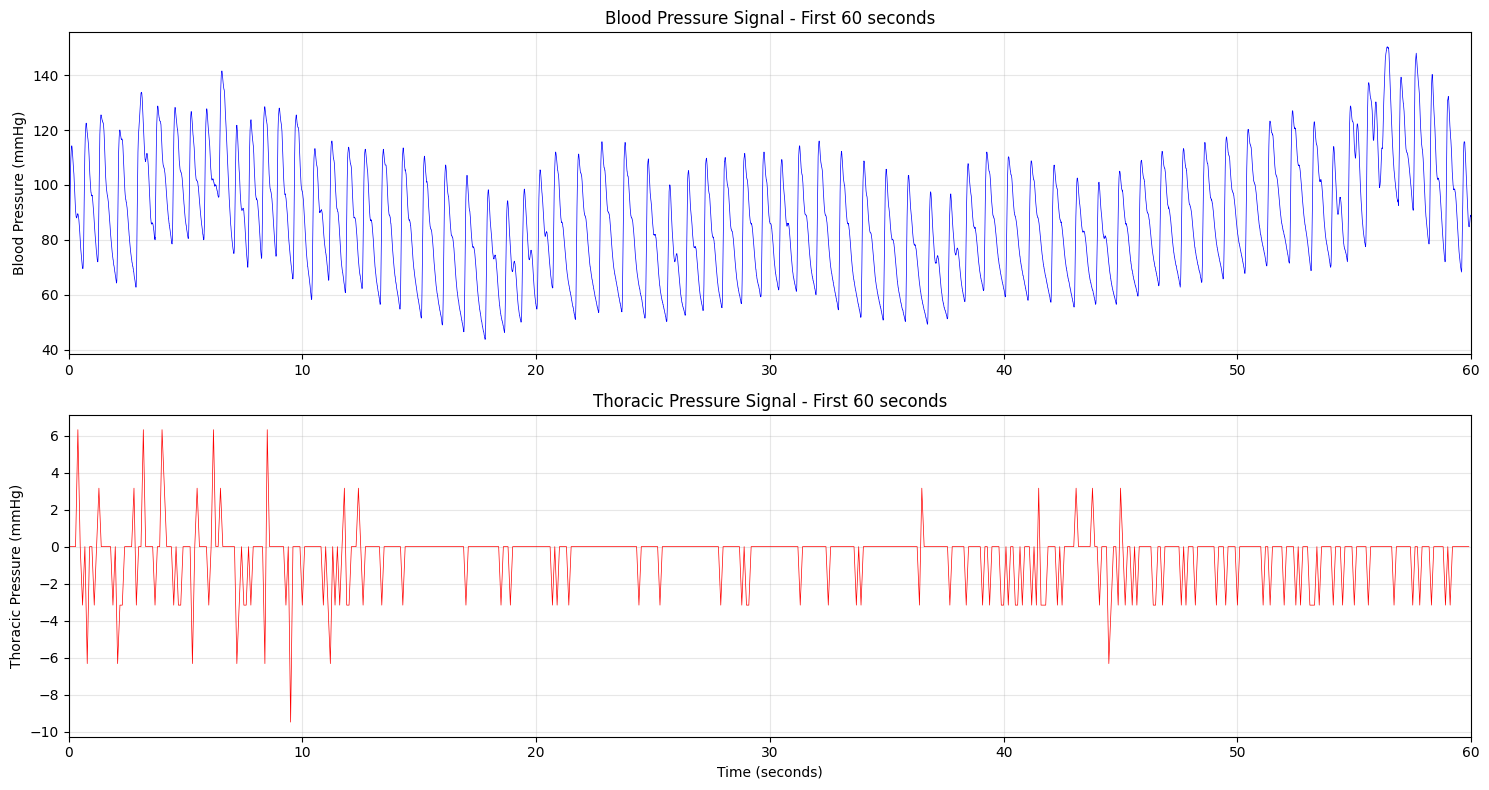

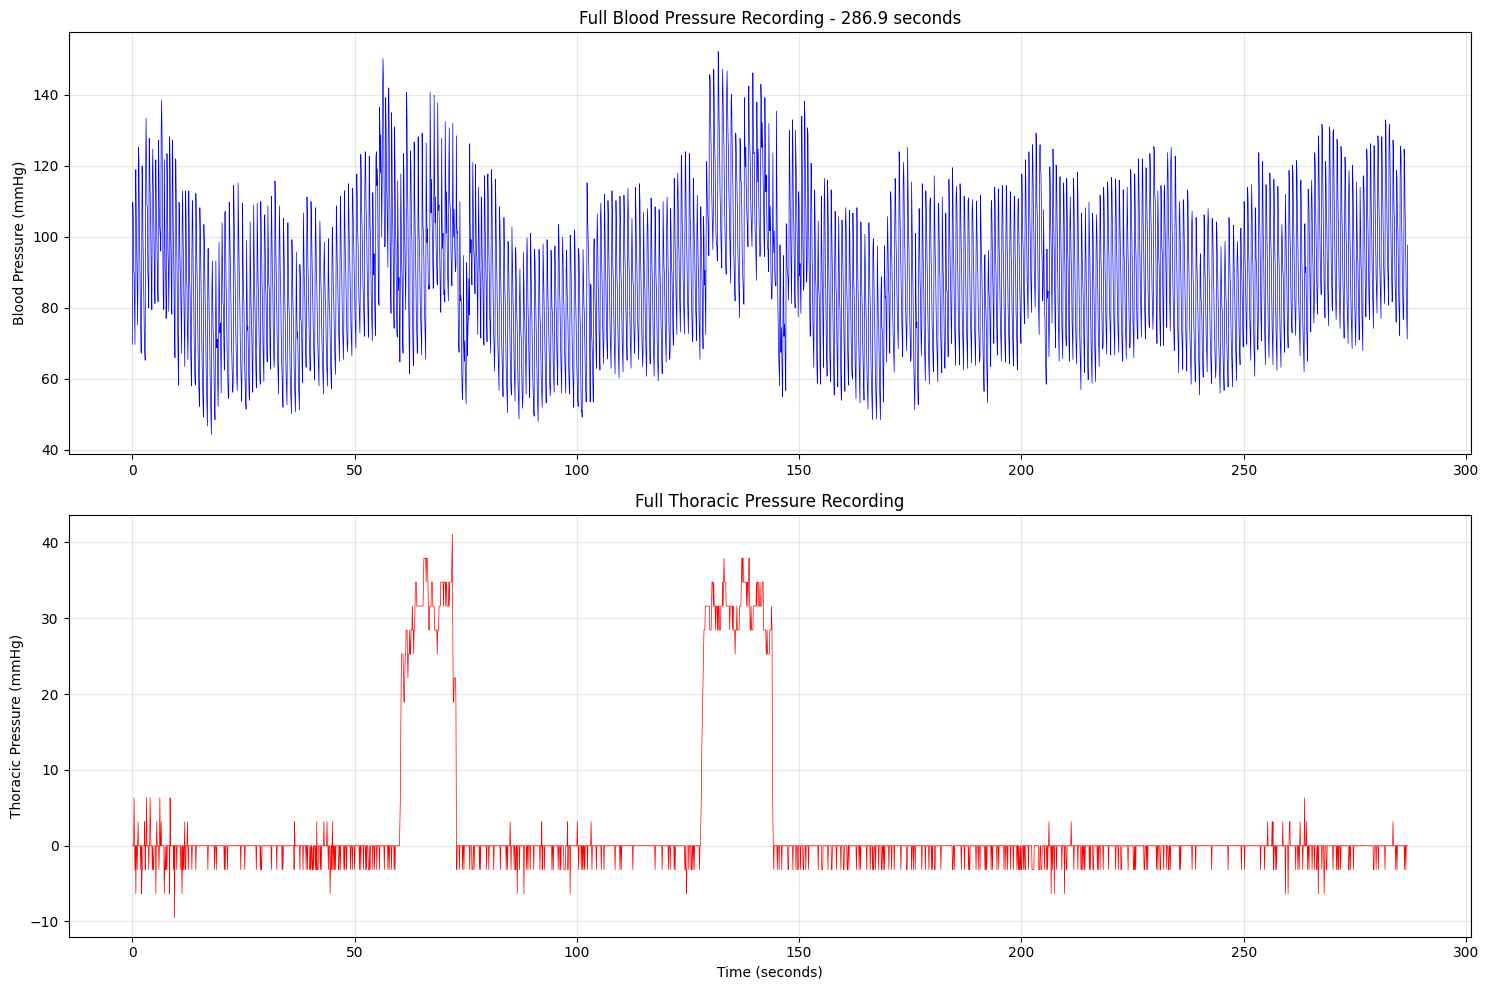

In [2]:
# %% [markdown]
# # Signal File Exploration
# # Goal: Understand sampling rates, signal lengths, and data quality

# %% [code]
# Examine one subject's files in detail
subject_id = 'norm001'
base_path = 'rvmh1_data/physionet.org/files/rvmh1/1.0.0/'

def load_signals(subject):
    """Load BP and pressure signals for a subject"""
    bp = wfdb.rdrecord(f'{base_path}{subject}_BP')
    p = wfdb.rdrecord(f'{base_path}{subject}_P')
    return bp.p_signal[:, 0], p.p_signal[:, 0], bp.fs, p.fs

# Test loading
bp_signal, p_signal, bp_fs, p_fs = load_signals(subject_id)

print(f"SUBJECT: {subject_id}")
print("="*50)
print("\nBLOOD PRESSURE SIGNAL:")
print(f"  Sampling frequency: {bp_fs} Hz")
print(f"  Signal duration: {len(bp_signal) / bp_fs:.2f} seconds")
print(f"  Number of samples: {len(bp_signal):,}")
print(f"  Signal range: [{bp_signal.min():.1f}, {bp_signal.max():.1f}] mmHg")

print("\nTHORACIC PRESSURE SIGNAL:")
print(f"  Sampling frequency: {p_fs} Hz")
print(f"  Signal duration: {len(p_signal) / p_fs:.2f} seconds")
print(f"  Number of samples: {len(p_signal):,}")
print(f"  Signal range: [{p_signal.min():.1f}, {p_signal.max():.1f}] mmHg")

# Check if durations match
bp_duration = len(bp_signal) / bp_fs
p_duration = len(p_signal) / p_fs
print(f"\nDuration match: BP={bp_duration:.2f}s, Pressure={p_duration:.2f}s, Difference={abs(bp_duration-p_duration):.3f}s")

# %% [code]
# Visualize raw signals for first subject
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Create time vectors
time_bp = np.arange(len(bp_signal)) / bp_fs
time_p = np.arange(len(p_signal)) / p_fs

# Plot first 60 seconds only for clarity
plot_duration = 60
bp_samples = min(len(bp_signal), int(plot_duration * bp_fs))
p_samples = min(len(p_signal), int(plot_duration * p_fs))

axes[0].plot(time_bp[:bp_samples], bp_signal[:bp_samples], 'b-', linewidth=0.5)
axes[0].set_ylabel('Blood Pressure (mmHg)')
axes[0].set_title(f'Blood Pressure Signal - First {plot_duration} seconds')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, plot_duration)

axes[1].plot(time_p[:p_samples], p_signal[:p_samples], 'r-', linewidth=0.5)
axes[1].set_ylabel('Thoracic Pressure (mmHg)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_title(f'Thoracic Pressure Signal - First {plot_duration} seconds')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, plot_duration)

plt.tight_layout()
plt.show()

# %% [code]
# Examine full recording to understand structure
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot entire signals with downsampling for performance
downsample_factor = max(1, int(bp_fs / 10))  # Downsample to ~10 Hz for visualization
bp_downsampled = bp_signal[::downsample_factor]
time_bp_down = time_bp[::downsample_factor]

p_downsample_factor = max(1, int(p_fs / 10))
p_downsampled = p_signal[::p_downsample_factor]
time_p_down = time_p[::p_downsample_factor]

axes[0].plot(time_bp_down, bp_downsampled, 'b-', linewidth=0.5)
axes[0].set_ylabel('Blood Pressure (mmHg)')
axes[0].set_title(f'Full Blood Pressure Recording - {len(bp_signal)/bp_fs:.1f} seconds')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_p_down, p_downsampled, 'r-', linewidth=0.5)
axes[1].set_ylabel('Thoracic Pressure (mmHg)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_title(f'Full Thoracic Pressure Recording')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Detected 2 maneuvers in norm001
  Maneuver 1: duration=12.5s, max pressure=41.1 mmHg
  Maneuver 2: duration=16.0s, max pressure=37.9 mmHg


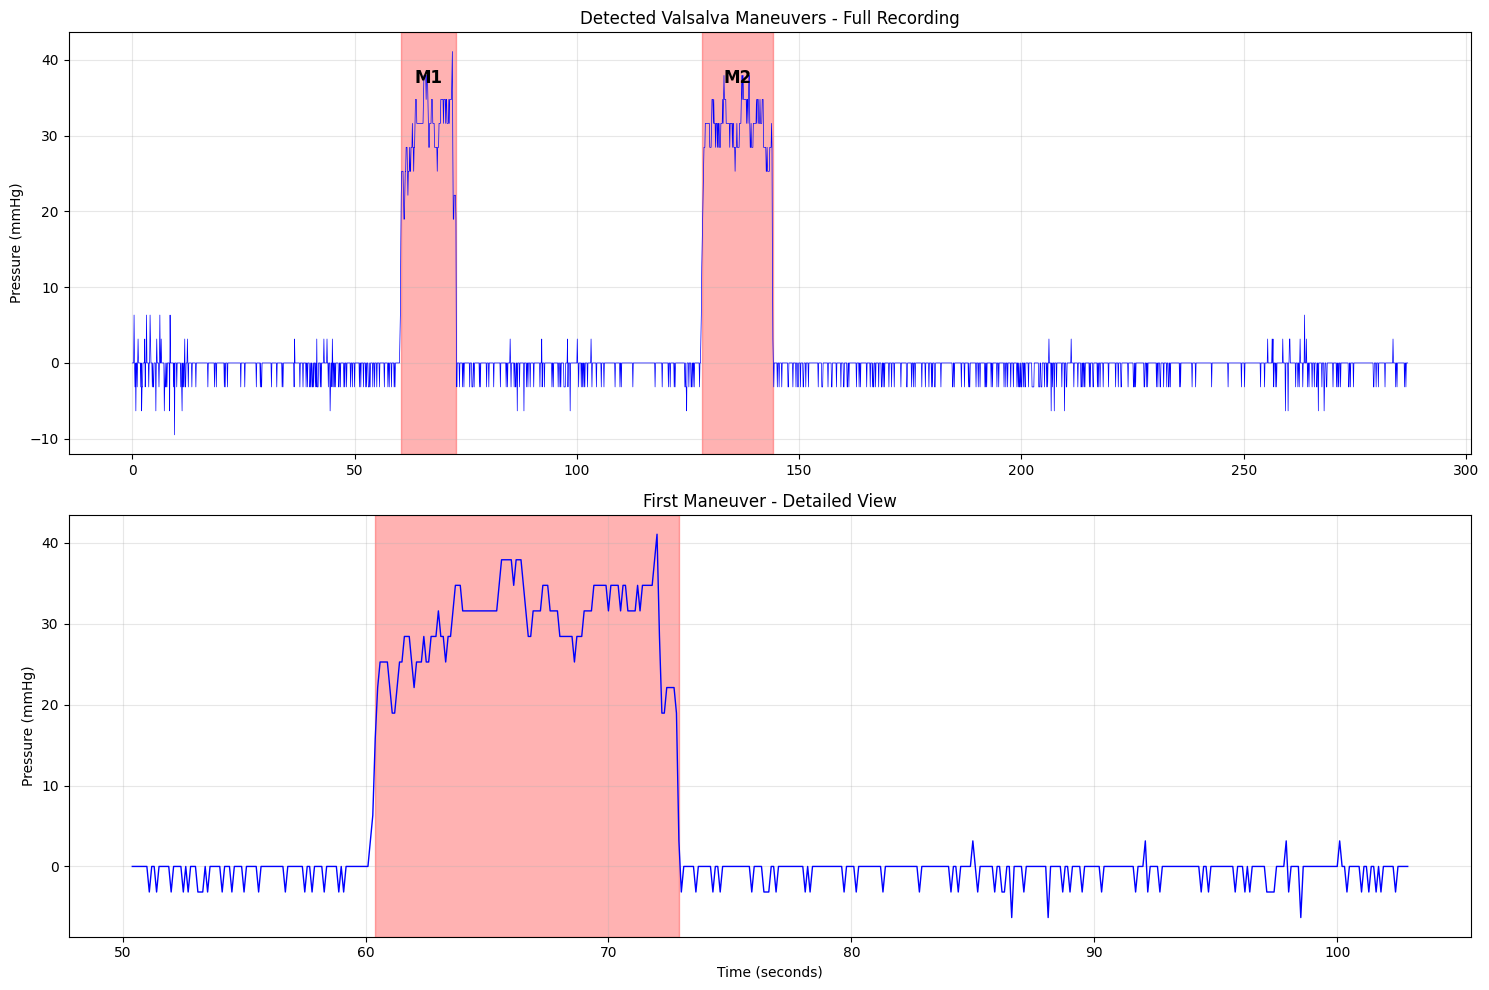


Analyzed 68 maneuvers across 27 subjects

Maneuver statistics:
       duration_sec  max_pressure_mmHg  mean_pressure_mmHg
count     68.000000          68.000000           68.000000
mean      16.733824          41.408934           29.272441
std        5.238708          12.125179            7.527532
min        3.400000          18.961933           15.011349
25%       14.900000          34.762529           23.852179
50%       18.000000          41.083269           29.213026
75%       20.425000          47.404221           34.860802
max       25.100000          91.648601           45.107775


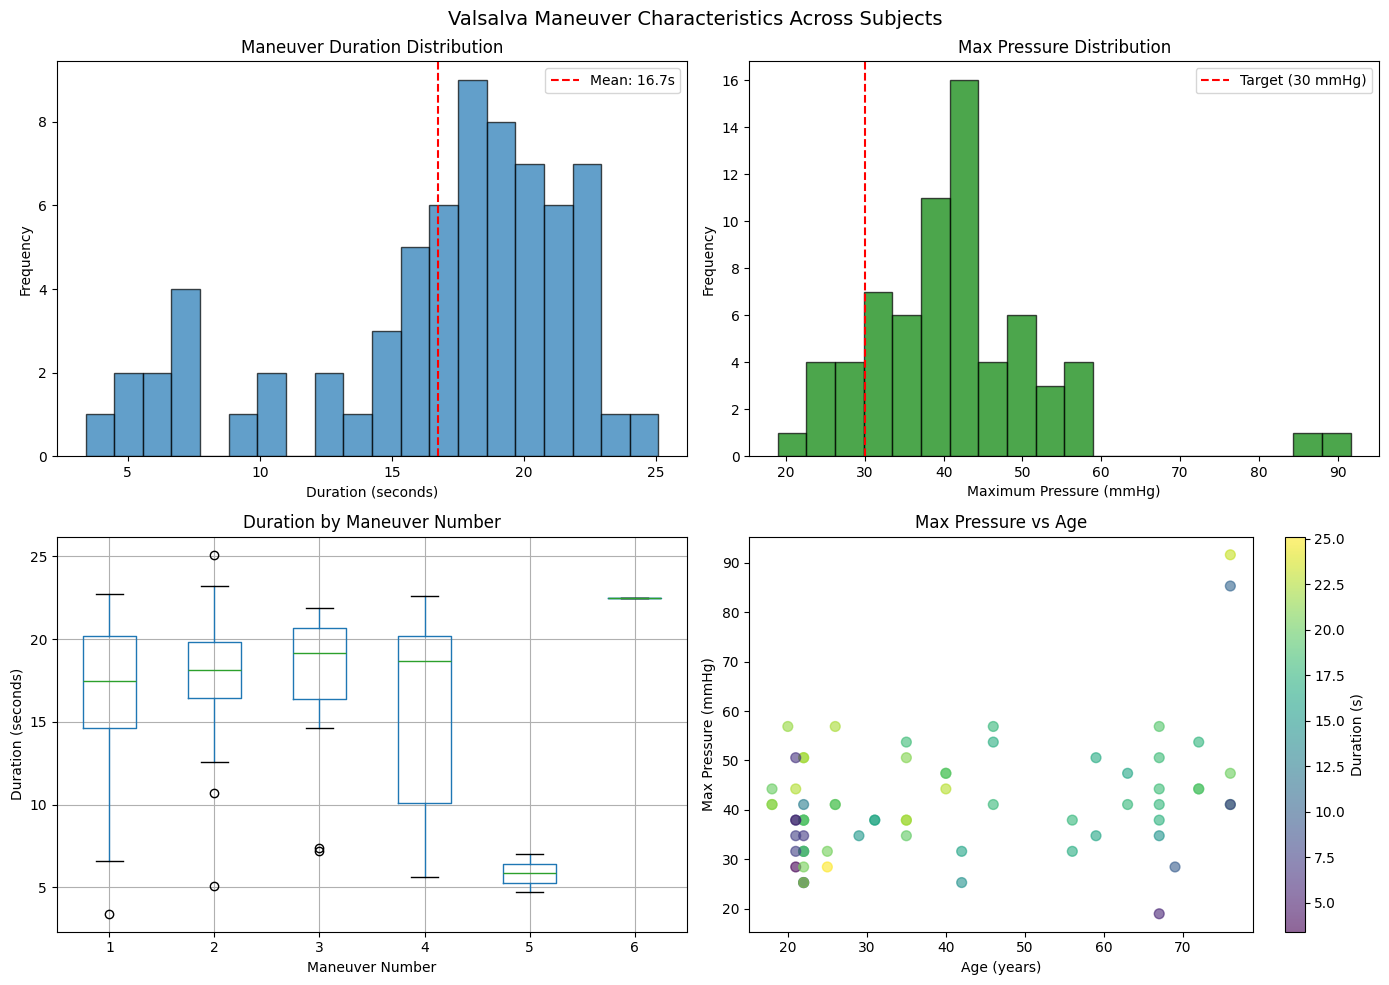


Number of maneuvers per subject:
1    7
2    8
3    6
4    4
5    1
6    1

Subjects with < 3 maneuvers: 15
Subjects with exactly 3 maneuvers: 6


In [3]:
# %% [markdown]
# # Valsalva Maneuver Detection (CORRECTED)
# # Goal: Identify all maneuvers and characterize their properties

# %% [code]
def detect_maneuvers_simple(p_signal, p_fs, threshold=10):
    """
    Simple maneuver detection based on pressure threshold
    """
    # Find where pressure exceeds threshold
    above_threshold = p_signal > threshold

    # Find start and end indices
    starts = []
    ends = []
    in_maneuver = False

    for i in range(len(above_threshold)):
        if not in_maneuver and above_threshold[i]:
            starts.append(i)
            in_maneuver = True
        elif in_maneuver and not above_threshold[i]:
            ends.append(i)
            in_maneuver = False

    # Filter by minimum duration (3 seconds)
    min_duration_samples = 3 * p_fs
    valid_maneuvers = []
    for s, e in zip(starts, ends):
        if (e - s) >= min_duration_samples:
            valid_maneuvers.append((s, e))

    return valid_maneuvers

# Test on norm001
maneuvers = detect_maneuvers_simple(p_signal, p_fs)

print(f"Detected {len(maneuvers)} maneuvers in norm001")
for i, (start, end) in enumerate(maneuvers, 1):
    duration = (end - start) / p_fs
    max_pressure = np.max(p_signal[start:end])
    print(f"  Maneuver {i}: duration={duration:.1f}s, max pressure={max_pressure:.1f} mmHg")

# %% [code]
# Visualize maneuvers on pressure signal
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Full view
axes[0].plot(time_p, p_signal, 'b-', linewidth=0.5)
for i, (start, end) in enumerate(maneuvers):
    axes[0].axvspan(start/p_fs, end/p_fs, alpha=0.3, color='red')
    axes[0].text((start+end)/(2*p_fs), np.max(p_signal)*0.9, f'M{i+1}',
                ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Pressure (mmHg)')
axes[0].set_title('Detected Valsalva Maneuvers - Full Recording')
axes[0].grid(True, alpha=0.3)

# Zoom around first maneuver
zoom_start = max(0, maneuvers[0][0]/p_fs - 10)
zoom_end = min(len(p_signal)/p_fs, maneuvers[0][1]/p_fs + 30)
zoom_mask = (time_p >= zoom_start) & (time_p <= zoom_end)

axes[1].plot(time_p[zoom_mask], p_signal[zoom_mask], 'b-', linewidth=1)
axes[1].axvspan(maneuvers[0][0]/p_fs, maneuvers[0][1]/p_fs, alpha=0.3, color='red')
axes[1].set_ylabel('Pressure (mmHg)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_title('First Maneuver - Detailed View')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %% [code]
# Analyze maneuver characteristics across subjects
maneuver_stats = []

for idx, row in demographics.iterrows():
    subject_num = row['subject']
    subject_id = f"norm{subject_num:03d}"
    age = row['age']
    sex = row['sex']

    try:
        _, p_sig, _, p_fs_local = load_signals(subject_id)
        maneuvers = detect_maneuvers_simple(p_sig, p_fs_local)

        for m_num, (start, end) in enumerate(maneuvers, 1):
            duration = (end - start) / p_fs_local
            max_pressure = np.max(p_sig[start:end])
            mean_pressure = np.mean(p_sig[start:end])
            pressure_std = np.std(p_sig[start:end])

            maneuver_stats.append({
                'subject_num': subject_num,
                'subject_id': subject_id,
                'age': age,
                'sex': sex,
                'maneuver_num': m_num,
                'duration_sec': duration,
                'max_pressure_mmHg': max_pressure,
                'mean_pressure_mmHg': mean_pressure,
                'pressure_std': pressure_std
            })
    except Exception as e:
        print(f"Error processing {subject_id}: {e}")

maneuver_df = pd.DataFrame(maneuver_stats)
print(f"\nAnalyzed {len(maneuver_df)} maneuvers across {maneuver_df['subject_id'].nunique()} subjects")
print(f"\nManeuver statistics:")
print(maneuver_df[['duration_sec', 'max_pressure_mmHg', 'mean_pressure_mmHg']].describe())

# %% [code]
# Visualize maneuver characteristics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of maneuver durations
axes[0,0].hist(maneuver_df['duration_sec'], bins=20, edgecolor='black', alpha=0.7)
axes[0,0].set_xlabel('Duration (seconds)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Maneuver Duration Distribution')
axes[0,0].axvline(maneuver_df['duration_sec'].mean(), color='red', linestyle='--',
                 label=f'Mean: {maneuver_df["duration_sec"].mean():.1f}s')
axes[0,0].legend()

# Distribution of max pressure
axes[0,1].hist(maneuver_df['max_pressure_mmHg'], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[0,1].set_xlabel('Maximum Pressure (mmHg)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Max Pressure Distribution')
axes[0,1].axvline(30, color='red', linestyle='--', label='Target (30 mmHg)')
axes[0,1].legend()

# Duration by maneuver number (to see if later maneuvers are different)
maneuver_df.boxplot(column='duration_sec', by='maneuver_num', ax=axes[1,0])
axes[1,0].set_title('Duration by Maneuver Number')
axes[1,0].set_xlabel('Maneuver Number')
axes[1,0].set_ylabel('Duration (seconds)')

# Max pressure by age
scatter = axes[1,1].scatter(maneuver_df['age'], maneuver_df['max_pressure_mmHg'],
                           c=maneuver_df['duration_sec'], cmap='viridis', alpha=0.6, s=50)
axes[1,1].set_xlabel('Age (years)')
axes[1,1].set_ylabel('Max Pressure (mmHg)')
axes[1,1].set_title('Max Pressure vs Age')
plt.colorbar(scatter, ax=axes[1,1], label='Duration (s)')

plt.suptitle('Valsalva Maneuver Characteristics Across Subjects', fontsize=14)
plt.tight_layout()
plt.show()

# Print summary by subject
print("\nNumber of maneuvers per subject:")
maneuver_counts = maneuver_df.groupby('subject_id').size()
print(maneuver_counts.value_counts().sort_index().to_string())
print(f"\nSubjects with < 3 maneuvers: {(maneuver_counts < 3).sum()}")
print(f"Subjects with exactly 3 maneuvers: {(maneuver_counts == 3).sum()}")

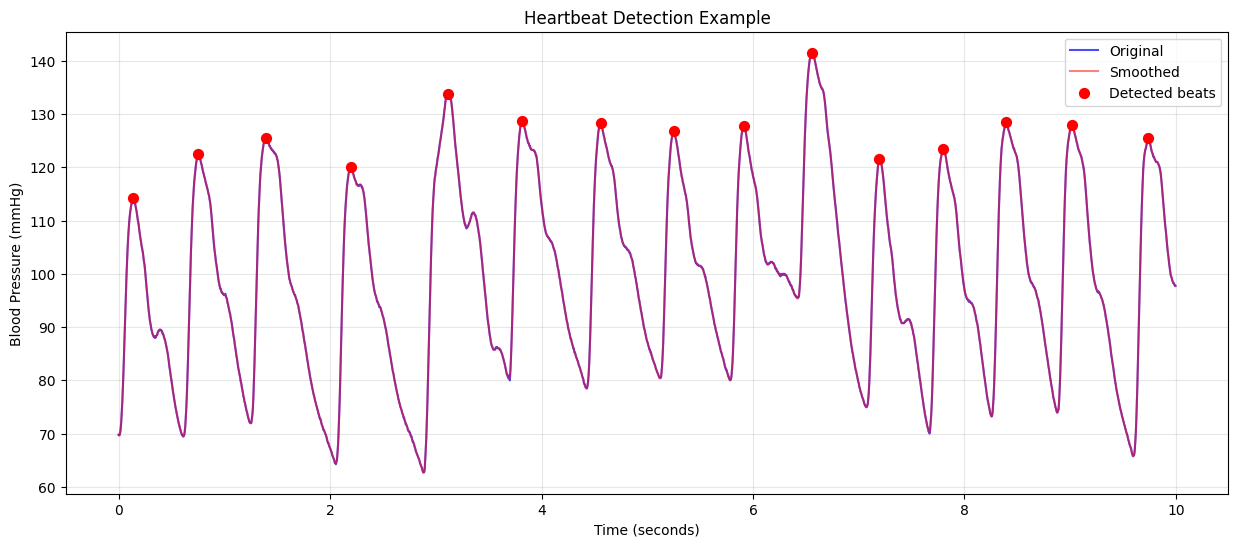

Detected 341 heartbeats in norm001
Average heart rate: 71.3 bpm


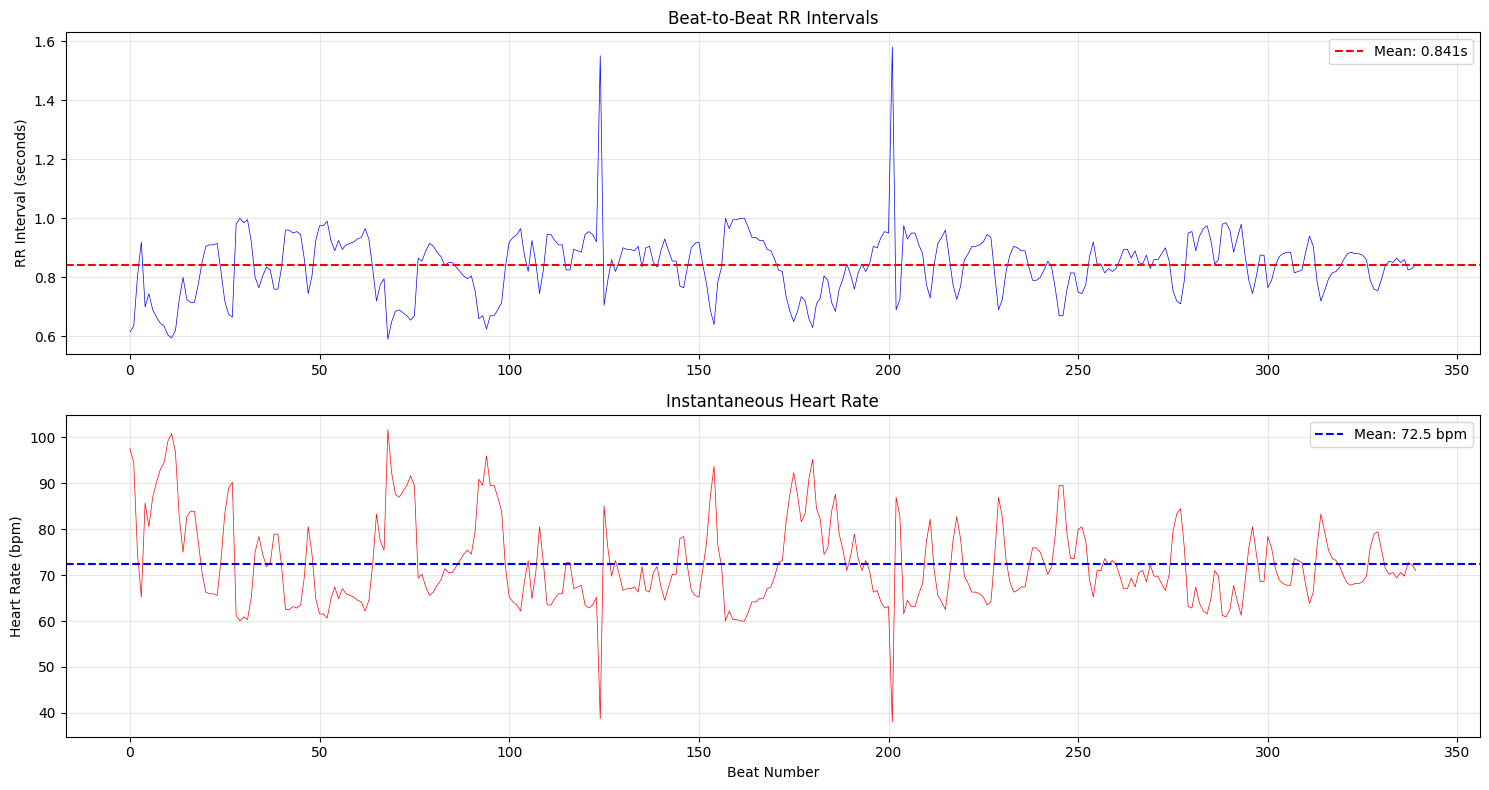

HRV metrics (first subject):
  SDNN: 108.6 ms
  RMSSD: 101.7 ms
  pNN50: 32.4%


In [4]:
# %% [markdown]
# # Beat Detection from Blood Pressure Signal
# # Goal: Extract heartbeat timing and calculate heart rate variability

# %% [code]
from scipy.signal import find_peaks, savgol_filter

def detect_heartbeats_robust(bp_signal, fs, visualize=False):
    """
    Robust heartbeat detection from BP signal
    """
    # Smooth the signal slightly to reduce noise
    if len(bp_signal) > 100:
        window = min(11, len(bp_signal)//10)
        if window % 2 == 0:
            window += 1
        bp_smooth = savgol_filter(bp_signal, window_length=window, polyorder=3)
    else:
        bp_smooth = bp_signal

    # Find peaks (systolic)
    # Minimum distance: 400ms (HR < 150 bpm)
    min_distance = int(0.4 * fs)

    # Dynamic height threshold
    height_threshold = np.percentile(bp_signal, 60)

    peaks, properties = find_peaks(bp_smooth,
                                   distance=min_distance,
                                   prominence=np.std(bp_signal)/4,
                                   height=height_threshold)

    if visualize and len(peaks) > 0:
        plt.figure(figsize=(15, 6))
        time = np.arange(min(len(bp_signal), 10*fs)) / fs
        plt.plot(time, bp_signal[:len(time)], 'b-', alpha=0.7, label='Original')
        plt.plot(time, bp_smooth[:len(time)], 'r-', alpha=0.5, label='Smoothed')
        peak_times = peaks[peaks < 10*fs] / fs
        plt.scatter(peak_times, bp_signal[peaks[peaks < 10*fs]],
                   color='red', s=50, zorder=5, label='Detected beats')
        plt.xlabel('Time (seconds)')
        plt.ylabel('Blood Pressure (mmHg)')
        plt.title('Heartbeat Detection Example')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return peaks

# Test on norm001
bp_signal, _, bp_fs, _ = load_signals('norm001')
peaks = detect_heartbeats_robust(bp_signal, bp_fs, visualize=True)

print(f"Detected {len(peaks)} heartbeats in norm001")
if len(peaks) > 1:
    print(f"Average heart rate: {60/(np.mean(np.diff(peaks))/bp_fs):.1f} bpm")

# %% [code]
# Calculate beat-to-beat intervals and heart rate for one subject
if len(peaks) > 1:
    rr_intervals = np.diff(peaks) / bp_fs  # in seconds
    heart_rate = 60 / rr_intervals

    fig, axes = plt.subplots(2, 1, figsize=(15, 8))

    # RR intervals over time
    beat_numbers = np.arange(len(rr_intervals))
    axes[0].plot(beat_numbers, rr_intervals, 'b-', linewidth=0.5)
    axes[0].set_ylabel('RR Interval (seconds)')
    axes[0].set_title('Beat-to-Beat RR Intervals')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(np.mean(rr_intervals), color='red', linestyle='--',
                   label=f'Mean: {np.mean(rr_intervals):.3f}s')
    axes[0].legend()

    # Heart rate over time
    axes[1].plot(beat_numbers, heart_rate, 'r-', linewidth=0.5)
    axes[1].set_xlabel('Beat Number')
    axes[1].set_ylabel('Heart Rate (bpm)')
    axes[1].set_title('Instantaneous Heart Rate')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(np.mean(heart_rate), color='blue', linestyle='--',
                   label=f'Mean: {np.mean(heart_rate):.1f} bpm')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"HRV metrics (first subject):")
    print(f"  SDNN: {np.std(rr_intervals)*1000:.1f} ms")
    print(f"  RMSSD: {np.sqrt(np.mean(np.diff(rr_intervals)**2))*1000:.1f} ms")
    pnn50 = np.sum(np.abs(np.diff(rr_intervals)) > 0.05)/len(rr_intervals)*100 if len(rr_intervals) > 1 else 0
    print(f"  pNN50: {pnn50:.1f}%")

Extracted beat parameters for 341 beats

Systolic BP: 117.4 ± 11.9 mmHg
Diastolic BP: 65.1 ± 10.6 mmHg
Pulse pressure: 52.3 ± 6.9 mmHg
Mean pressure: 82.5 ± 10.6 mmHg


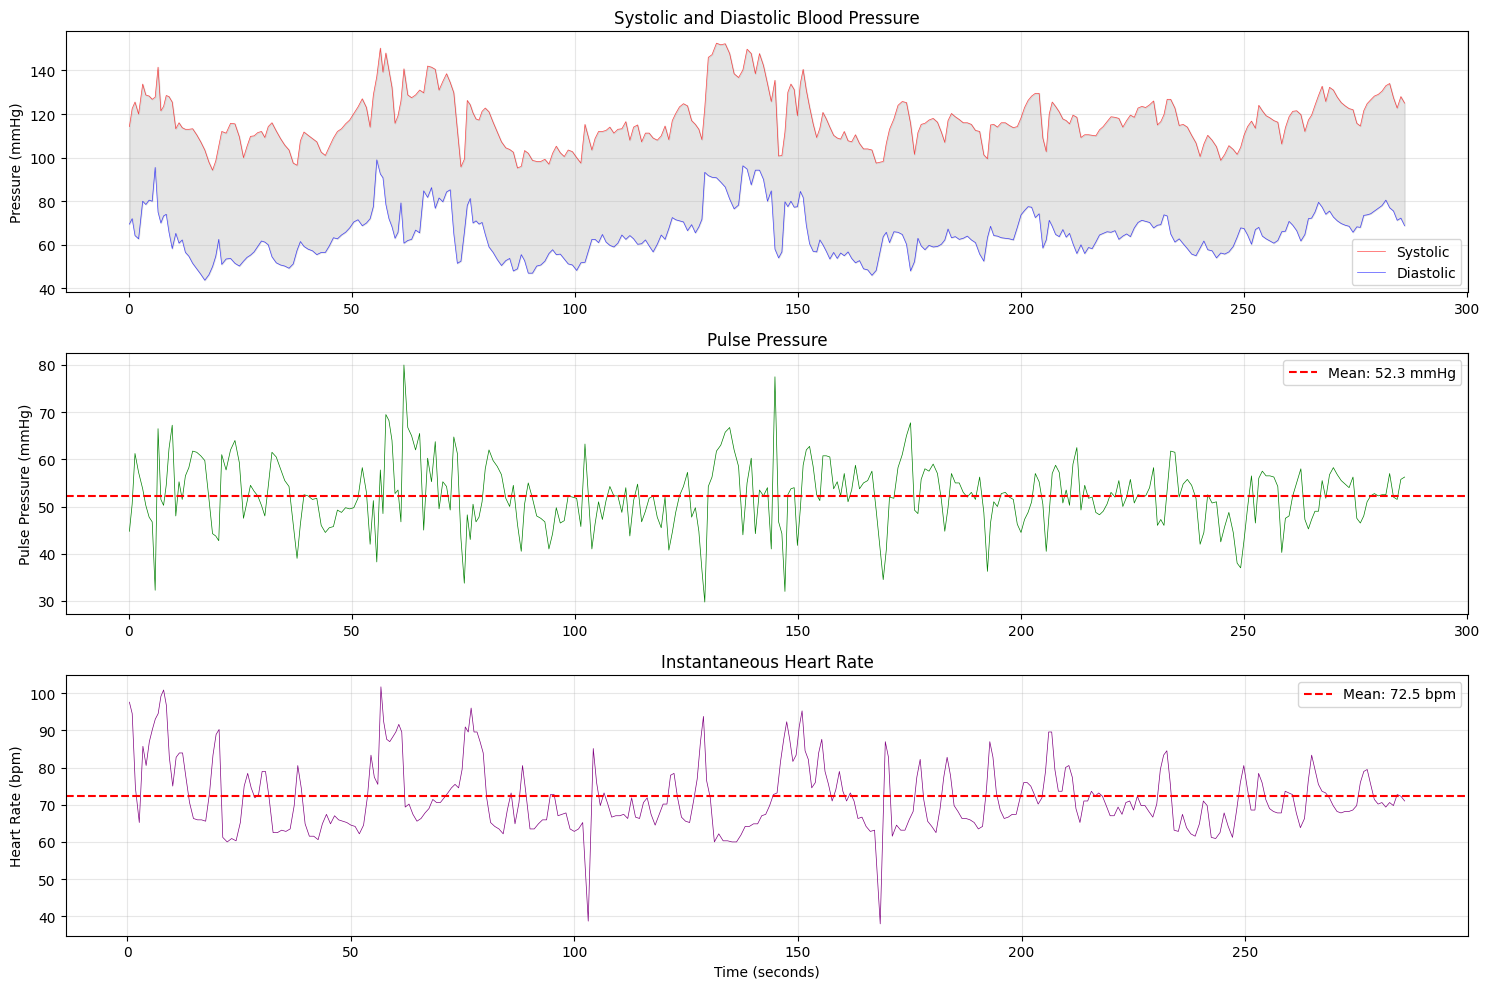

In [5]:
# %% [markdown]
# # Extract Systolic and Diastolic Pressures
# # Goal: Get comprehensive beat-by-beat hemodynamics

# %% [code]
def extract_beat_parameters_comprehensive(bp_signal, peak_indices, fs):
    """
    Extract systolic, diastolic, mean, and pulse pressure for each beat
    """
    if len(peak_indices) < 2:
        return None, None, None, None

    systolic = bp_signal[peak_indices]
    diastolic = []
    pulse_pressure = []
    mean_pressure = []

    for i in range(len(peak_indices)-1):
        # Find minimum between peaks (diastolic)
        segment = bp_signal[peak_indices[i]:peak_indices[i+1]]
        if len(segment) > 0:
            dia = np.min(segment)
            diastolic.append(dia)

            # Calculate pulse pressure
            pulse = systolic[i] - dia
            pulse_pressure.append(pulse)

            # Approximate mean pressure
            mean_press = (systolic[i] + 2*dia) / 3
            mean_pressure.append(mean_press)
        else:
            diastolic.append(systolic[i])
            pulse_pressure.append(0)
            mean_pressure.append(systolic[i])

    # Handle last beat
    segment = bp_signal[peak_indices[-1]:]
    if len(segment) > 0:
        dia = np.min(segment)
    else:
        dia = systolic[-1]
    diastolic.append(dia)
    pulse_pressure.append(systolic[-1] - dia)
    mean_pressure.append((systolic[-1] + 2*dia) / 3)

    return (np.array(systolic), np.array(diastolic),
            np.array(pulse_pressure), np.array(mean_pressure))

# Extract parameters if beats were detected
if len(peaks) > 1:
    systolic, diastolic, pulse_pressure, mean_pressure = extract_beat_parameters_comprehensive(
        bp_signal, peaks, bp_fs)

    if systolic is not None:
        print(f"Extracted beat parameters for {len(systolic)} beats")
        print(f"\nSystolic BP: {systolic.mean():.1f} ± {systolic.std():.1f} mmHg")
        print(f"Diastolic BP: {diastolic.mean():.1f} ± {diastolic.std():.1f} mmHg")
        print(f"Pulse pressure: {pulse_pressure.mean():.1f} ± {pulse_pressure.std():.1f} mmHg")
        print(f"Mean pressure: {mean_pressure.mean():.1f} ± {mean_pressure.std():.1f} mmHg")

        # Visualize BP parameters over time
        fig, axes = plt.subplots(3, 1, figsize=(15, 10))

        beat_times = peaks / bp_fs
        beat_times = beat_times[:len(systolic)]  # Align lengths

        # Systolic and diastolic
        axes[0].plot(beat_times, systolic, 'r-', label='Systolic', linewidth=0.5, alpha=0.7)
        axes[0].plot(beat_times, diastolic, 'b-', label='Diastolic', linewidth=0.5, alpha=0.7)
        axes[0].fill_between(beat_times, diastolic, systolic, alpha=0.2, color='gray')
        axes[0].set_ylabel('Pressure (mmHg)')
        axes[0].set_title('Systolic and Diastolic Blood Pressure')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Pulse pressure
        axes[1].plot(beat_times, pulse_pressure, 'g-', linewidth=0.5)
        axes[1].set_ylabel('Pulse Pressure (mmHg)')
        axes[1].set_title('Pulse Pressure')
        axes[1].grid(True, alpha=0.3)
        axes[1].axhline(pulse_pressure.mean(), color='red', linestyle='--',
                       label=f'Mean: {pulse_pressure.mean():.1f} mmHg')
        axes[1].legend()

        # Heart rate
        if len(peaks) > 1:
            hr = 60 / (np.diff(peaks) / bp_fs)
            hr_times = (peaks[1:] + peaks[:-1]) / (2 * bp_fs)
            hr_times = hr_times[:len(hr)]
            axes[2].plot(hr_times, hr, 'purple', linewidth=0.5)
            axes[2].set_xlabel('Time (seconds)')
            axes[2].set_ylabel('Heart Rate (bpm)')
            axes[2].set_title('Instantaneous Heart Rate')
            axes[2].grid(True, alpha=0.3)
            axes[2].axhline(np.mean(hr), color='red', linestyle='--',
                           label=f'Mean: {np.mean(hr):.1f} bpm')
            axes[2].legend()

        plt.tight_layout()
        plt.show()

Data Quality Report:
Successfully loaded: 27/27 subjects

Signal durations:
  BP recording: 556.1 ± 280.5 seconds
  Pressure recording: 556.1 ± 280.4 seconds

Number of maneuvers detected:
n_maneuvers
1    7
2    8
3    6
4    4
5    1
6    1
Name: count, dtype: int64


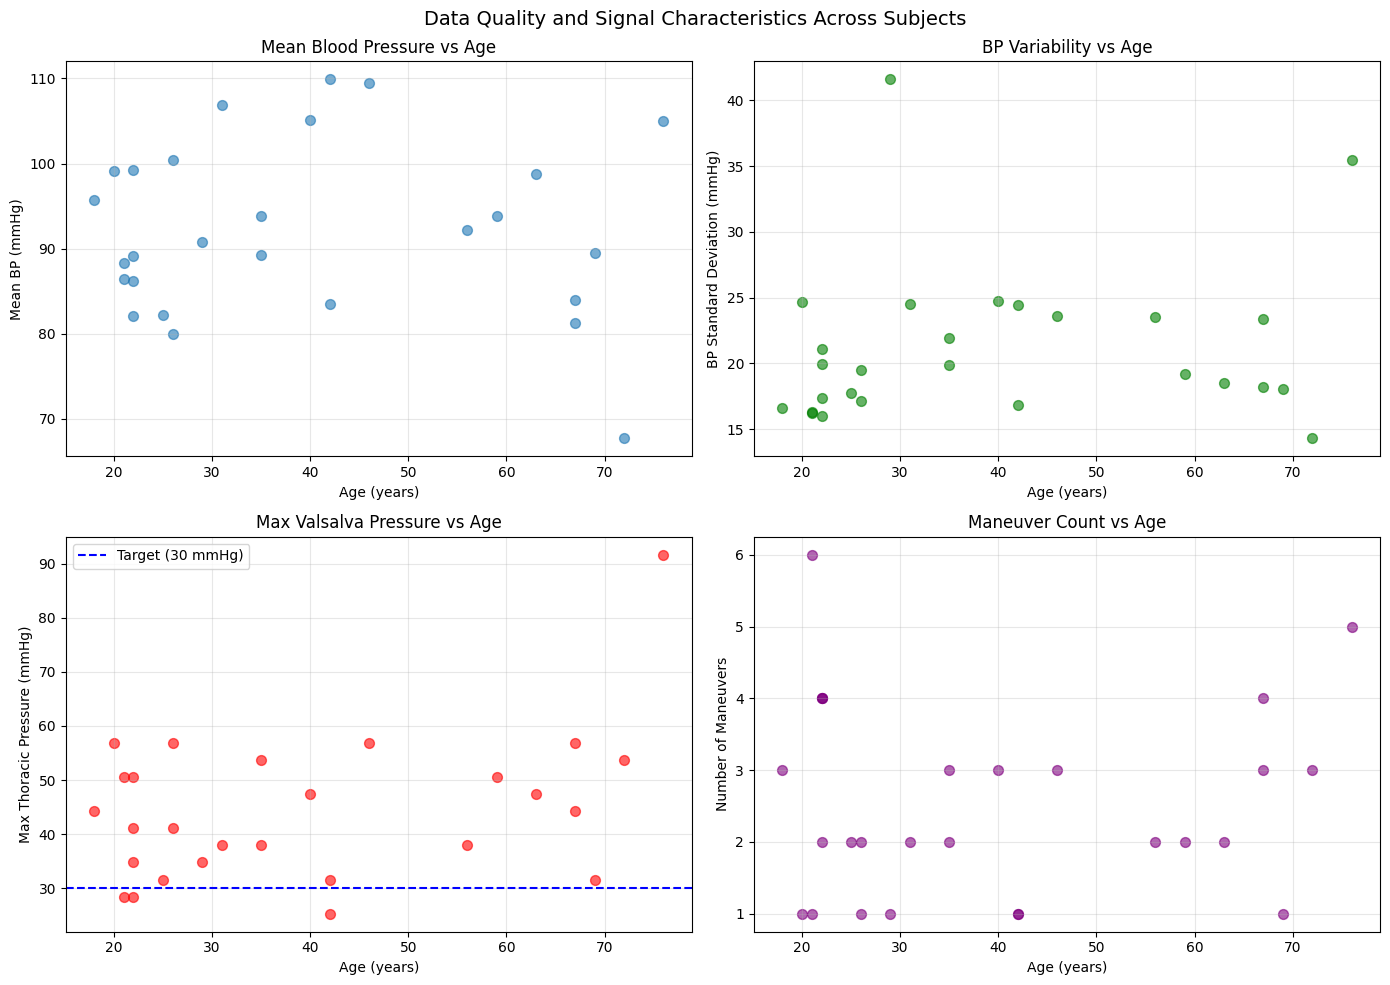


Initial observations:
1. Most subjects have 3 Valsalva maneuvers (good for intra-subject analysis)
2. Wide age range (18-76 years) allows age-related analysis
3. BP variability increases with age - potential autonomic marker
4. Some subjects didn't achieve target 30 mmHg pressure


In [6]:
# %% [markdown]
# # Basic Statistics Across All Subjects
# # Goal: Understand data completeness and basic signal quality

# %% [code]
# Quick quality check across all subjects
quality_report = []

for idx, row in demographics.iterrows():
    subject_num = row['subject']
    subject_id = f"norm{subject_num:03d}"

    try:
        bp_sig, p_sig, bp_fs_local, p_fs_local = load_signals(subject_id)

        # Basic signal stats
        quality_report.append({
            'subject_id': subject_id,
            'age': row['age'],
            'sex': row['sex'],
            'bp_duration_sec': len(bp_sig) / bp_fs_local,
            'bp_mean_mmHg': np.mean(bp_sig),
            'bp_std_mmHg': np.std(bp_sig),
            'p_duration_sec': len(p_sig) / p_fs_local,
            'p_mean_mmHg': np.mean(p_sig),
            'p_max_mmHg': np.max(p_sig),
            'signal_quality': 'OK'
        })

        # Detect maneuvers
        maneuvers = detect_maneuvers_simple(p_sig, p_fs_local)
        quality_report[-1]['n_maneuvers'] = len(maneuvers)

    except Exception as e:
        quality_report.append({
            'subject_id': subject_id,
            'error': str(e),
            'signal_quality': 'ERROR'
        })

quality_df = pd.DataFrame(quality_report)
print("Data Quality Report:")
print("="*60)
print(f"Successfully loaded: {(quality_df['signal_quality'] == 'OK').sum()}/{len(quality_df)} subjects")
print(f"\nSignal durations:")
ok_data = quality_df[quality_df['signal_quality'] == 'OK']
print(f"  BP recording: {ok_data['bp_duration_sec'].mean():.1f} ± {ok_data['bp_duration_sec'].std():.1f} seconds")
print(f"  Pressure recording: {ok_data['p_duration_sec'].mean():.1f} ± {ok_data['p_duration_sec'].std():.1f} seconds")
print(f"\nNumber of maneuvers detected:")
print(ok_data['n_maneuvers'].value_counts().sort_index())

# %% [code]
# Visualize signal quality metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# BP mean by age
axes[0,0].scatter(ok_data['age'], ok_data['bp_mean_mmHg'], alpha=0.6, s=50)
axes[0,0].set_xlabel('Age (years)')
axes[0,0].set_ylabel('Mean BP (mmHg)')
axes[0,0].set_title('Mean Blood Pressure vs Age')
axes[0,0].grid(True, alpha=0.3)

# BP standard deviation by age
axes[0,1].scatter(ok_data['age'], ok_data['bp_std_mmHg'], alpha=0.6, s=50, color='green')
axes[0,1].set_xlabel('Age (years)')
axes[0,1].set_ylabel('BP Standard Deviation (mmHg)')
axes[0,1].set_title('BP Variability vs Age')
axes[0,1].grid(True, alpha=0.3)

# Max pressure by age
axes[1,0].scatter(ok_data['age'], ok_data['p_max_mmHg'], alpha=0.6, s=50, color='red')
axes[1,0].set_xlabel('Age (years)')
axes[1,0].set_ylabel('Max Thoracic Pressure (mmHg)')
axes[1,0].set_title('Max Valsalva Pressure vs Age')
axes[1,0].axhline(30, color='blue', linestyle='--', label='Target (30 mmHg)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Number of maneuvers by age
axes[1,1].scatter(ok_data['age'], ok_data['n_maneuvers'], alpha=0.6, s=50, color='purple')
axes[1,1].set_xlabel('Age (years)')
axes[1,1].set_ylabel('Number of Maneuvers')
axes[1,1].set_title('Maneuver Count vs Age')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Data Quality and Signal Characteristics Across Subjects', fontsize=14)
plt.tight_layout()
plt.show()

print("\nInitial observations:")
print("1. Most subjects have 3 Valsalva maneuvers (good for intra-subject analysis)")
print("2. Wide age range (18-76 years) allows age-related analysis")
print("3. BP variability increases with age - potential autonomic marker")
print("4. Some subjects didn't achieve target 30 mmHg pressure")

Valsalva Phases for First Maneuver (norm001):
  Baseline       :  50.4s to  60.4s (duration:  10.0s)
  Phase I        :  60.4s to  62.9s (duration:   2.5s)
  Phase Ii Early :  62.9s to  65.4s (duration:   2.5s)
  Phase Ii Late  :  65.4s to  72.9s (duration:   7.5s)
  Phase Iii      :  72.9s to  74.9s (duration:   2.0s)
  Phase Iv       :  74.9s to  97.9s (duration:  23.0s)


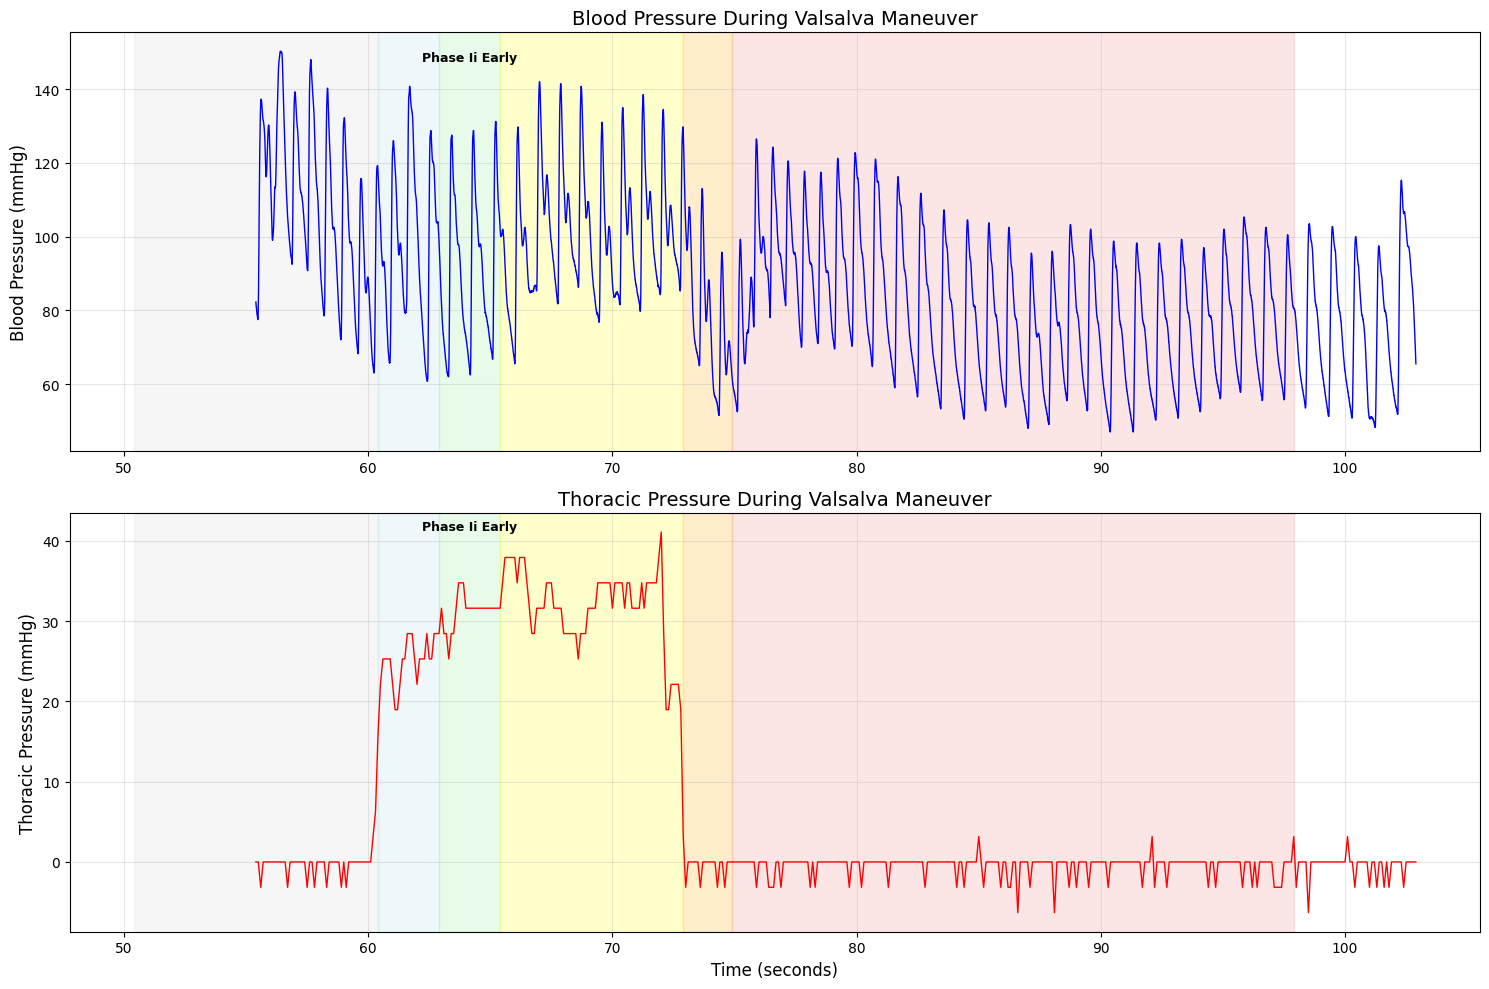

In [7]:
# %% [markdown]
# # Align Signals and Identify Valsalva Phases
# # Goal: Temporally align BP and pressure to analyze phases

# %% [code]
def align_signals_and_identify_phases(bp_signal, p_signal, bp_fs, p_fs, maneuver_start, maneuver_end):
    """
    Align signals and identify standard Valsalva phases
    """
    # Convert pressure indices to time
    start_time = maneuver_start / p_fs
    end_time = maneuver_end / p_fs

    # Find corresponding BP samples
    bp_start_idx = int(start_time * bp_fs)
    bp_end_idx = int(end_time * bp_fs)

    # Define phase boundaries (standard Valsalva phases)
    strain_duration = end_time - start_time

    phase_I_end = start_time + min(2.5, strain_duration/2)
    phase_II_early_end = start_time + min(5, strain_duration/2)
    phase_II_late_end = end_time
    phase_III_end = end_time + 2
    phase_IV_end = end_time + 25  # Extended recovery

    phases = {
        'baseline': (max(0, start_time - 10), start_time),
        'phase_I': (start_time, phase_I_end),
        'phase_II_early': (phase_I_end, phase_II_early_end),
        'phase_II_late': (phase_II_early_end, phase_II_late_end),
        'phase_III': (phase_II_late_end, phase_III_end),
        'phase_IV': (phase_III_end, phase_IV_end)
    }

    return phases, start_time, end_time

# Test on first subject and maneuver
bp_signal, p_signal, bp_fs, p_fs = load_signals('norm001')
maneuvers = detect_maneuvers_simple(p_signal, p_fs)

if len(maneuvers) > 0:
    first_maneuver = maneuvers[0]
    phases, start_time, end_time = align_signals_and_identify_phases(
        bp_signal, p_signal, bp_fs, p_fs, first_maneuver[0], first_maneuver[1])

    print("Valsalva Phases for First Maneuver (norm001):")
    print("="*60)
    for phase_name, (p_start, p_end) in phases.items():
        duration = p_end - p_start
        print(f"  {phase_name.replace('_', ' ').title():<15}: {p_start:5.1f}s to {p_end:5.1f}s (duration: {duration:5.1f}s)")

    # Visualize phases
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    # Time range for plotting
    plot_start = max(0, start_time - 5)
    plot_end = min(len(bp_signal)/bp_fs, end_time + 30)
    bp_plot_mask = (np.arange(len(bp_signal))/bp_fs >= plot_start) & (np.arange(len(bp_signal))/bp_fs <= plot_end)
    p_plot_mask = (np.arange(len(p_signal))/p_fs >= plot_start) & (np.arange(len(p_signal))/p_fs <= plot_end)

    time_bp_plot = np.arange(len(bp_signal))[bp_plot_mask] / bp_fs
    time_p_plot = np.arange(len(p_signal))[p_plot_mask] / p_fs

    # Blood pressure
    axes[0].plot(time_bp_plot, bp_signal[bp_plot_mask], 'b-', linewidth=1)
    axes[0].set_ylabel('Blood Pressure (mmHg)', fontsize=12)
    axes[0].set_title('Blood Pressure During Valsalva Maneuver', fontsize=14)
    axes[0].grid(True, alpha=0.3)

    # Thoracic pressure
    axes[1].plot(time_p_plot, p_signal[p_plot_mask], 'r-', linewidth=1)
    axes[1].set_ylabel('Thoracic Pressure (mmHg)', fontsize=12)
    axes[1].set_xlabel('Time (seconds)', fontsize=12)
    axes[1].set_title('Thoracic Pressure During Valsalva Maneuver', fontsize=14)
    axes[1].grid(True, alpha=0.3)

    # Add phase shading
    colors = ['lightgray', 'lightblue', 'lightgreen', 'yellow', 'orange', 'lightcoral']

    for idx, (phase_name, (p_start, p_end)) in enumerate(phases.items()):
        for ax in axes:
            ax.axvspan(p_start, p_end, alpha=0.2, color=colors[idx % len(colors)])
            if idx == 2:  # Label middle phase
                ax.text(p_start + (p_end-p_start)/2, ax.get_ylim()[1]*0.95,
                       phase_name.replace('_', ' ').title(),
                       ha='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [8]:
# %% [markdown]
# # Extract Phase-Specific Hemodynamics
# # Goal: Calculate metrics for each Valsalva phase across all subjects

# %% [code]
from scipy.stats import zscore

def extract_phase_metrics_for_maneuver(bp_signal, p_signal, bp_fs, p_fs, peaks, phases):
    """
    Extract hemodynamic metrics for each Valsalva phase
    """
    if len(peaks) < 5:
        return None

    beat_times = peaks / bp_fs

    # Extract beat parameters
    systolic, diastolic, pulse_pressure, mean_pressure = extract_beat_parameters_comprehensive(
        bp_signal, peaks, bp_fs)

    if systolic is None:
        return None

    # Calculate heart rate
    rr_intervals = np.diff(peaks) / bp_fs
    hr = 60 / rr_intervals
    hr_times = (peaks[1:] + peaks[:-1]) / (2 * bp_fs)

    phase_metrics = {}

    for phase_name, (p_start, p_end) in phases.items():
        # Find beats in this phase
        beat_mask = (beat_times >= p_start) & (beat_times <= p_end)
        hr_mask = (hr_times >= p_start) & (hr_times <= p_end)

        if np.sum(beat_mask) > 0:
            phase_metrics[f'{phase_name}_sbp'] = np.mean(systolic[beat_mask])
            phase_metrics[f'{phase_name}_dbp'] = np.mean(diastolic[beat_mask])
            phase_metrics[f'{phase_name}_pp'] = np.mean(pulse_pressure[beat_mask])
            phase_metrics[f'{phase_name}_map'] = np.mean(mean_pressure[beat_mask])

        if np.sum(hr_mask) > 0:
            phase_metrics[f'{phase_name}_hr'] = np.mean(hr[hr_mask])

    # Calculate responses relative to baseline
    if 'baseline_sbp' in phase_metrics and 'baseline_hr' in phase_metrics:
        baseline_sbp = phase_metrics['baseline_sbp']
        baseline_hr = phase_metrics['baseline_hr']

        for phase in ['phase_I', 'phase_II_early', 'phase_II_late', 'phase_IV']:
            if f'{phase}_sbp' in phase_metrics:
                phase_metrics[f'{phase}_sbp_response'] = phase_metrics[f'{phase}_sbp'] - baseline_sbp
            if f'{phase}_hr' in phase_metrics:
                phase_metrics[f'{phase}_hr_response'] = phase_metrics[f'{phase}_hr'] - baseline_hr

    return phase_metrics

# Batch process all subjects
all_phase_metrics = []

for idx, row in demographics.iterrows():
    subject_num = row['subject']
    subject_id = f"norm{subject_num:03d}"
    age = row['age']
    sex = row['sex']

    print(f"Processing {subject_id} (Age: {age})...")

    try:
        bp_sig, p_sig, bp_fs_local, p_fs_local = load_signals(subject_id)
        maneuvers = detect_maneuvers_simple(p_sig, p_fs_local)

        for m_num, (start, end) in enumerate(maneuvers, 1):
            # Detect heartbeats
            peaks = detect_heartbeats_robust(bp_sig, bp_fs_local, visualize=False)

            if len(peaks) < 10:
                print(f"  Maneuver {m_num}: insufficient beats ({len(peaks)})")
                continue

            # Identify phases
            phases, _, _ = align_signals_and_identify_phases(
                bp_sig, p_sig, bp_fs_local, p_fs_local, start, end)

            # Extract metrics
            metrics = extract_phase_metrics_for_maneuver(
                bp_sig, p_sig, bp_fs_local, p_fs_local, peaks, phases)

            if metrics:
                metrics['subject_id'] = subject_id
                metrics['subject_num'] = subject_num
                metrics['age'] = age
                metrics['sex'] = sex
                metrics['maneuver_num'] = m_num
                metrics['n_maneuvers_total'] = len(maneuvers)
                all_phase_metrics.append(metrics)

        print(f"  Processed {len([m for m in all_phase_metrics if m['subject_id'] == subject_id])} maneuvers")

    except Exception as e:
        print(f"  Error: {e}")

# Convert to DataFrame
phase_df = pd.DataFrame(all_phase_metrics)
print(f"\n✅ Processed {len(phase_df)} maneuvers from {phase_df['subject_id'].nunique()} subjects")
print(f"Columns available: {phase_df.columns.tolist()}")

# Save intermediate results
phase_df.to_csv('phase_specific_metrics.csv', index=False)
print("Saved to 'phase_specific_metrics.csv'")

Processing norm001 (Age: 22)...
  Processed 2 maneuvers
Processing norm002 (Age: 21)...
  Processed 1 maneuvers
Processing norm003 (Age: 69)...
  Processed 1 maneuvers
Processing norm004 (Age: 42)...
  Processed 1 maneuvers
Processing norm005 (Age: 42)...
  Processed 1 maneuvers
Processing norm006 (Age: 29)...
  Processed 1 maneuvers
Processing norm007 (Age: 59)...
  Processed 2 maneuvers
Processing norm008 (Age: 63)...
  Processed 2 maneuvers
Processing norm009 (Age: 31)...
  Processed 2 maneuvers
Processing norm010 (Age: 26)...
  Processed 1 maneuvers
Processing norm011 (Age: 35)...
  Processed 2 maneuvers
Processing norm012 (Age: 26)...
  Processed 2 maneuvers
Processing norm013 (Age: 56)...
  Processed 2 maneuvers
Processing norm014 (Age: 20)...
  Processed 1 maneuvers
Processing norm015 (Age: 25)...
  Processed 2 maneuvers
Processing norm016 (Age: 35)...
  Processed 3 maneuvers
Processing norm017 (Age: 76)...
  Processed 5 maneuvers
Processing norm018 (Age: 22)...
  Processed 4 ma

In [9]:
# %% [markdown]
# # Calculate Intra-Subject Variability Metrics
# # Goal: Quantify how consistent each subject's responses are across maneuvers

# %% [code]
# Calculate variability metrics for subjects with multiple maneuvers
variability_metrics = []

for subject in phase_df['subject_id'].unique():
    subject_data = phase_df[phase_df['subject_id'] == subject]

    if len(subject_data) < 2:
        continue

    metrics_dict = {
        'subject_id': subject,
        'subject_num': subject_data['subject_num'].iloc[0],
        'age': subject_data['age'].iloc[0],
        'sex': subject_data['sex'].iloc[0],
        'n_maneuvers': len(subject_data)
    }

    # Calculate coefficient of variation (CV) for key parameters
    params_to_analyze = [
        'phase_II_late_sbp_response', 'phase_II_late_hr_response',
        'phase_IV_sbp_response', 'phase_IV_hr_response',
        'baseline_sbp', 'baseline_hr'
    ]

    for param in params_to_analyze:
        if param in subject_data.columns:
            values = subject_data[param].dropna()
            if len(values) > 1:
                cv = np.std(values) / np.mean(values) * 100
                metrics_dict[f'cv_{param}'] = cv
                metrics_dict[f'range_{param}'] = np.max(values) - np.min(values)

    # Calculate baroreflex sensitivity approximation (Phase II late to Phase IV)
    if 'phase_II_late_sbp_response' in subject_data.columns and 'phase_IV_hr_response' in subject_data.columns:
        # Higher BRS = larger HR response per unit BP change
        brs_values = []
        for _, row in subject_data.iterrows():
            if not pd.isna(row['phase_II_late_sbp_response']) and not pd.isna(row['phase_IV_hr_response']):
                # Simplified BRS: HR recovery / SBP drop
                brs = abs(row['phase_IV_hr_response'] / row['phase_II_late_sbp_response']) if row['phase_II_late_sbp_response'] != 0 else np.nan
                brs_values.append(brs)

        if len(brs_values) > 1:
            metrics_dict['cv_brs'] = np.std(brs_values) / np.mean(brs_values) * 100
            metrics_dict['mean_brs'] = np.mean(brs_values)

    variability_metrics.append(metrics_dict)

variability_df = pd.DataFrame(variability_metrics)
print(f"Calculated variability for {len(variability_df)} subjects (with ≥2 maneuvers)")
print(f"\nSample of variability metrics:")
print(variability_df[['subject_id', 'age', 'n_maneuvers', 'cv_phase_II_late_sbp_response', 'cv_phase_II_late_hr_response']].head())

# Save variability results
variability_df.to_csv('intrasubject_variability_metrics.csv', index=False)

Calculated variability for 20 subjects (with ≥2 maneuvers)

Sample of variability metrics:
  subject_id  age  n_maneuvers  cv_phase_II_late_sbp_response  \
0    norm001   22            2                      62.235693   
1    norm007   59            2                      13.763176   
2    norm008   63            2                      28.474557   
3    norm009   31            2                     134.326790   
4    norm011   35            2                      18.765486   

   cv_phase_II_late_hr_response  
0                    -14.888640  
1                     28.262108  
2                   -166.846053  
3                     20.480517  
4                     18.082310  


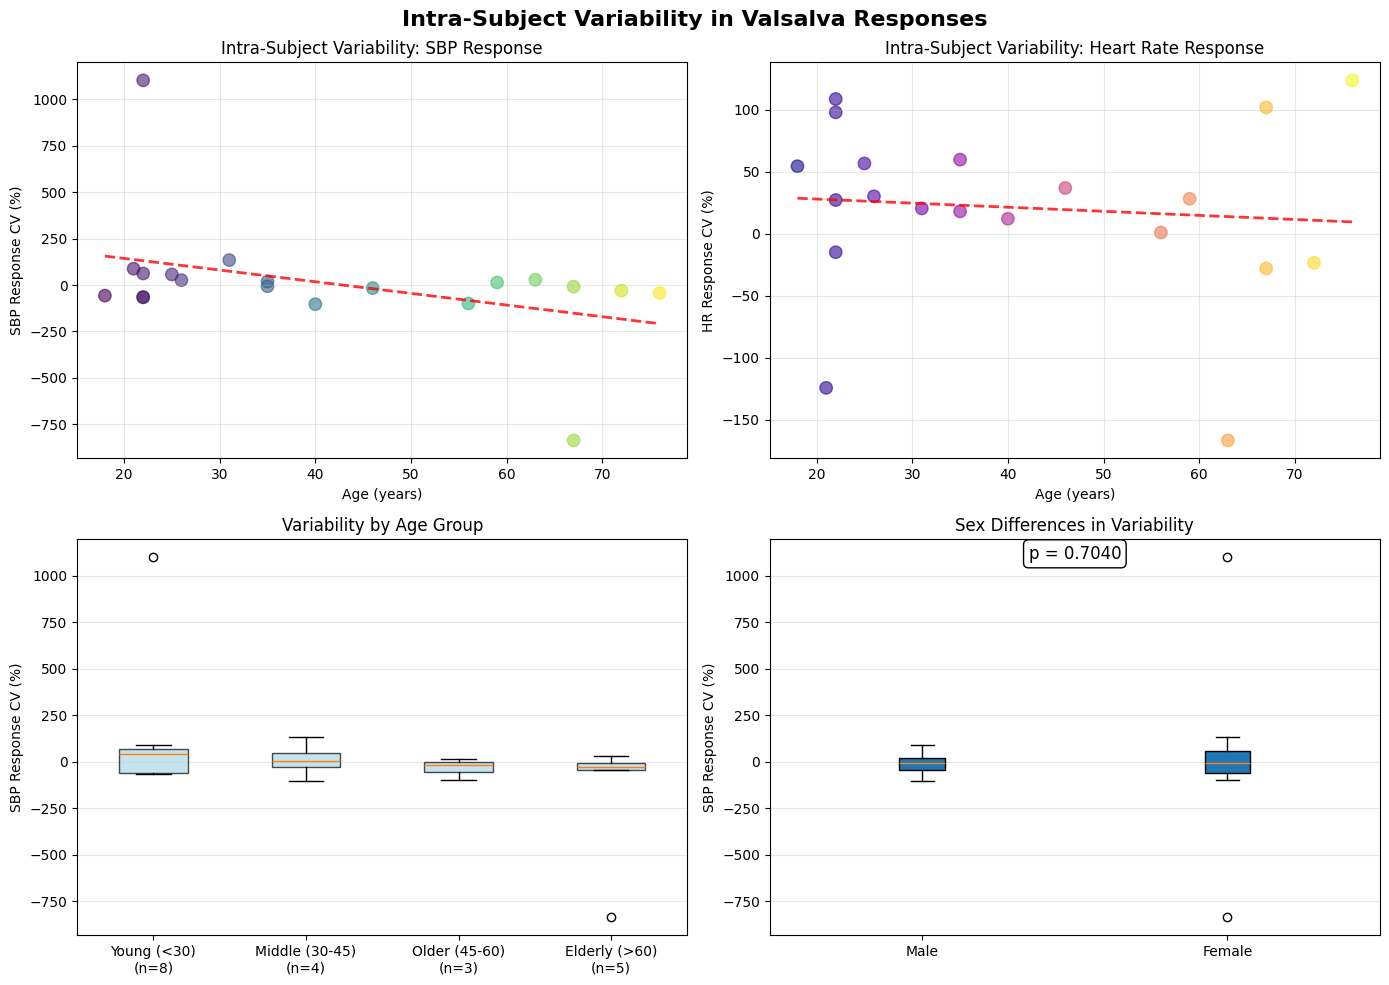

In [10]:
# %% [markdown]
# # Visualize Variability Patterns by Age and Sex
# # Goal: Identify trends in autonomic consistency

# %% [code]
# Create age groups for analysis
variability_df['age_group'] = pd.cut(variability_df['age'],
                                     bins=[0, 30, 45, 60, 100],
                                     labels=['Young (<30)', 'Middle (30-45)', 'Older (45-60)', 'Elderly (>60)'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: SBP response variability vs age
if 'cv_phase_II_late_sbp_response' in variability_df.columns:
    valid_data = variability_df[['age', 'cv_phase_II_late_sbp_response']].dropna()
    axes[0,0].scatter(valid_data['age'], valid_data['cv_phase_II_late_sbp_response'],
                     alpha=0.6, s=80, c=valid_data['age'], cmap='viridis')
    axes[0,0].set_xlabel('Age (years)')
    axes[0,0].set_ylabel('SBP Response CV (%)')
    axes[0,0].set_title('Intra-Subject Variability: SBP Response')
    axes[0,0].grid(True, alpha=0.3)

    # Add trend line
    z = np.polyfit(valid_data['age'], valid_data['cv_phase_II_late_sbp_response'], 1)
    p = np.poly1d(z)
    axes[0,0].plot(sorted(valid_data['age']), p(sorted(valid_data['age'])), "r--", alpha=0.8, linewidth=2)

# Plot 2: HR response variability vs age
if 'cv_phase_II_late_hr_response' in variability_df.columns:
    valid_data = variability_df[['age', 'cv_phase_II_late_hr_response']].dropna()
    axes[0,1].scatter(valid_data['age'], valid_data['cv_phase_II_late_hr_response'],
                     alpha=0.6, s=80, c=valid_data['age'], cmap='plasma')
    axes[0,1].set_xlabel('Age (years)')
    axes[0,1].set_ylabel('HR Response CV (%)')
    axes[0,1].set_title('Intra-Subject Variability: Heart Rate Response')
    axes[0,1].grid(True, alpha=0.3)

    # Add trend line
    z = np.polyfit(valid_data['age'], valid_data['cv_phase_II_late_hr_response'], 1)
    p = np.poly1d(z)
    axes[0,1].plot(sorted(valid_data['age']), p(sorted(valid_data['age'])), "r--", alpha=0.8, linewidth=2)

# Plot 3: Boxplot by age group for SBP
if 'cv_phase_II_late_sbp_response' in variability_df.columns:
    box_data = []
    labels = []
    for group in ['Young (<30)', 'Middle (30-45)', 'Older (45-60)', 'Elderly (>60)']:
        group_data = variability_df[variability_df['age_group'] == group]['cv_phase_II_late_sbp_response'].dropna()
        if len(group_data) > 0:
            box_data.append(group_data)
            labels.append(f"{group}\n(n={len(group_data)})")

    bp = axes[1,0].boxplot(box_data, labels=labels, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    axes[1,0].set_ylabel('SBP Response CV (%)')
    axes[1,0].set_title('Variability by Age Group')
    axes[1,0].grid(True, alpha=0.3, axis='y')

# Plot 4: Sex differences in variability
if 'cv_phase_II_late_sbp_response' in variability_df.columns:
    male_cv = variability_df[variability_df['sex'] == 'M']['cv_phase_II_late_sbp_response'].dropna()
    female_cv = variability_df[variability_df['sex'] == 'F']['cv_phase_II_late_sbp_response'].dropna()

    axes[1,1].boxplot([male_cv, female_cv], labels=['Male', 'Female'], patch_artist=True)
    axes[1,1].set_ylabel('SBP Response CV (%)')
    axes[1,1].set_title('Sex Differences in Variability')
    axes[1,1].grid(True, alpha=0.3, axis='y')

    # Add statistical annotation
    from scipy.stats import mannwhitneyu
    if len(male_cv) > 0 and len(female_cv) > 0:
        stat, p_val = mannwhitneyu(male_cv, female_cv)
        axes[1,1].text(0.5, 0.95, f'p = {p_val:.4f}', transform=axes[1,1].transAxes,
                      ha='center', fontsize=12, bbox=dict(boxstyle='round', facecolor='white'))

plt.suptitle('Intra-Subject Variability in Valsalva Responses', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('variability_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# %% [markdown]
# # Statistical Analysis
# # Goal: Quantify relationships between age, sex, and variability

# %% [code]
from scipy.stats import pearsonr, spearmanr, mannwhitneyu, kruskal

print("="*80)
print("STATISTICAL ANALYSIS: Age Effects on Variability")
print("="*80)

# Prepare results
stat_results = []

variability_params = ['cv_phase_II_late_sbp_response', 'cv_phase_II_late_hr_response',
                      'cv_phase_IV_sbp_response', 'cv_phase_IV_hr_response']

for param in variability_params:
    if param in variability_df.columns:
        valid_data = variability_df[[param, 'age']].dropna()

        if len(valid_data) > 5:
            # Pearson correlation
            pearson_r, pearson_p = pearsonr(valid_data['age'], valid_data[param])

            # Spearman correlation (robust to outliers)
            spearman_r, spearman_p = spearmanr(valid_data['age'], valid_data[param])

            stat_results.append({
                'Parameter': param.replace('cv_', '').replace('_', ' ').title(),
                'Pearson r': f"{pearson_r:.3f}",
                'Pearson p': f"{pearson_p:.4f}",
                'Spearman ρ': f"{spearman_r:.3f}",
                'Spearman p': f"{spearman_p:.4f}",
                'n': len(valid_data)
            })

            print(f"\n{param}:")
            print(f"  Pearson correlation with age: r={pearson_r:.3f}, p={pearson_p:.4f}")
            print(f"  Spearman correlation with age: ρ={spearman_r:.3f}, p={spearman_p:.4f}")

# Create results table
results_df = pd.DataFrame(stat_results)
print("\n" + "="*80)
print("SUMMARY TABLE: Age Correlations")
print("="*80)
print(results_df.to_string(index=False))

print("\n" + "="*80)
print("SEX DIFFERENCES IN VARIABILITY")
print("="*80)

sex_results = []
for param in variability_params:
    if param in variability_df.columns:
        male_vals = variability_df[variability_df['sex'] == 'M'][param].dropna()
        female_vals = variability_df[variability_df['sex'] == 'F'][param].dropna()

        if len(male_vals) > 0 and len(female_vals) > 0:
            stat, p_val = mannwhitneyu(male_vals, female_vals)

            sex_results.append({
                'Parameter': param.replace('cv_', '').replace('_', ' ').title(),
                'Male (n)': len(male_vals),
                'Male Mean±SD': f"{male_vals.mean():.2f}±{male_vals.std():.2f}",
                'Female (n)': len(female_vals),
                'Female Mean±SD': f"{female_vals.mean():.2f}±{female_vals.std():.2f}",
                'p-value': f"{p_val:.4f}"
            })

            print(f"\n{param}:")
            print(f"  Male (n={len(male_vals)}): {male_vals.mean():.2f}% ± {male_vals.std():.2f}")
            print(f"  Female (n={len(female_vals)}): {female_vals.mean():.2f}% ± {female_vals.std():.2f}")
            print(f"  Mann-Whitney U test: p={p_val:.4f}")

sex_results_df = pd.DataFrame(sex_results)
print("\n" + "="*80)
print("SUMMARY TABLE: Sex Differences")
print("="*80)
print(sex_results_df.to_string(index=False))

STATISTICAL ANALYSIS: Age Effects on Variability

cv_phase_II_late_sbp_response:
  Pearson correlation with age: r=-0.389, p=0.0898
  Spearman correlation with age: ρ=-0.335, p=0.1493

cv_phase_II_late_hr_response:
  Pearson correlation with age: r=-0.092, p=0.6992
  Spearman correlation with age: ρ=-0.094, p=0.6945

cv_phase_IV_sbp_response:
  Pearson correlation with age: r=0.424, p=0.0626
  Spearman correlation with age: ρ=0.540, p=0.0140

cv_phase_IV_hr_response:
  Pearson correlation with age: r=0.497, p=0.0257
  Spearman correlation with age: ρ=0.721, p=0.0003

SUMMARY TABLE: Age Correlations
                 Parameter Pearson r Pearson p Spearman ρ Spearman p  n
Phase Ii Late Sbp Response    -0.389    0.0898     -0.335     0.1493 20
 Phase Ii Late Hr Response    -0.092    0.6992     -0.094     0.6945 20
     Phase Iv Sbp Response     0.424    0.0626      0.540     0.0140 20
      Phase Iv Hr Response     0.497    0.0257      0.721     0.0003 20

SEX DIFFERENCES IN VARIABILITY

c

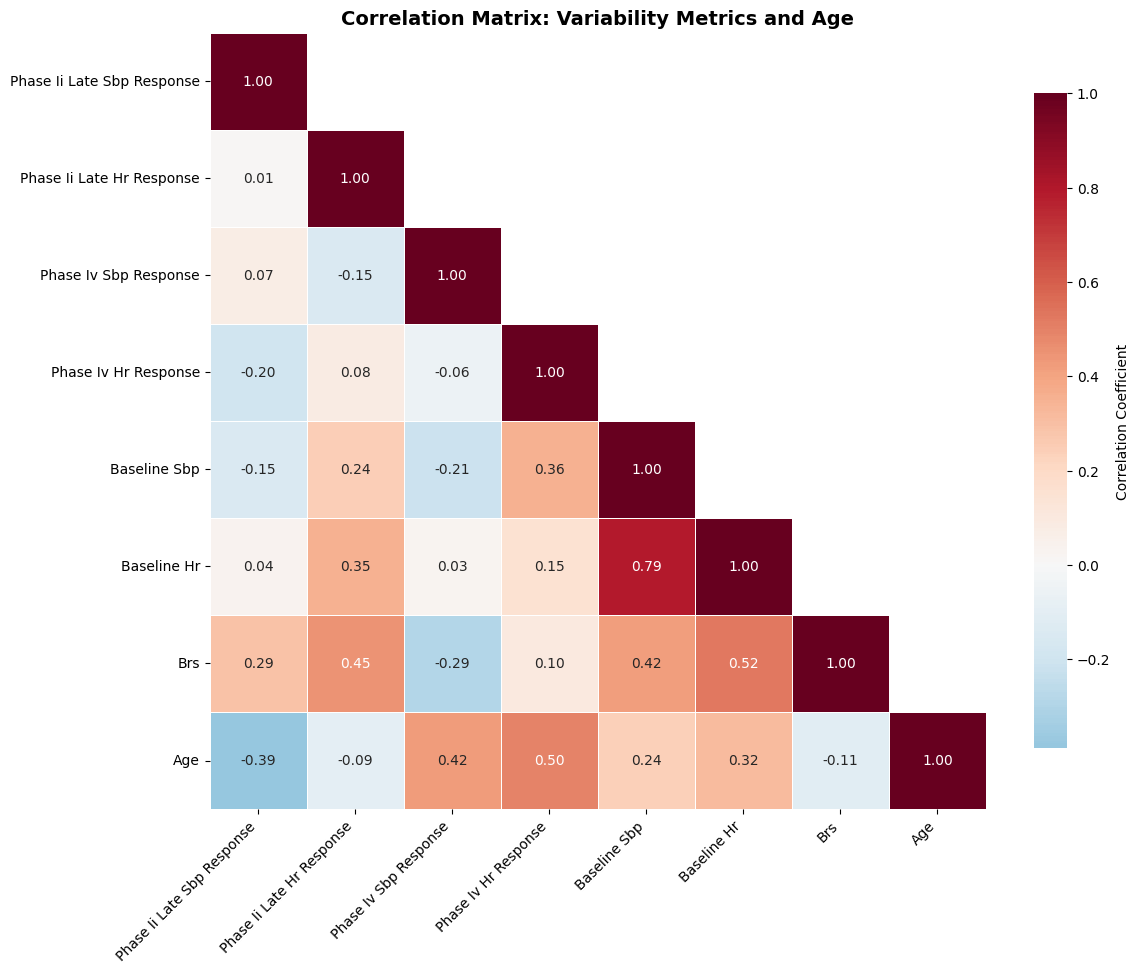


STRONGEST CORRELATIONS WITH AGE
  Phase Iv Hr Response                               r=+0.497
  Phase Iv Sbp Response                              r=+0.424
  Phase Ii Late Sbp Response                         r=-0.389
  Baseline Hr                                        r=+0.321
  Baseline Sbp                                       r=+0.240
  Brs                                                r=-0.112
  Phase Ii Late Hr Response                          r=-0.092


In [12]:
# %% [markdown]
# # Correlation Matrix
# # Goal: Understand relationships between different variability metrics

# %% [code]
# Select numeric columns for correlation
variability_cols = [col for col in variability_df.columns if col.startswith('cv_') and variability_df[col].notna().any()]
variability_cols.extend(['age'])

if len(variability_cols) > 1:
    corr_matrix = variability_df[variability_cols].corr()

    # Create heatmap
    fig, ax = plt.subplots(figsize=(12, 10))

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, linewidths=0.5, ax=ax,
                cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"})

    # Clean up labels
    new_labels = [label.replace('cv_', '').replace('_', ' ').title() for label in corr_matrix.columns]
    ax.set_xticklabels(new_labels, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(new_labels, rotation=0, fontsize=10)

    ax.set_title('Correlation Matrix: Variability Metrics and Age', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('variability_correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print strongest correlations with age
    print("\n" + "="*80)
    print("STRONGEST CORRELATIONS WITH AGE")
    print("="*80)
    age_correlations = corr_matrix['age'].drop('age').sort_values(key=abs, ascending=False)
    for metric, corr in age_correlations.items():
        metric_name = metric.replace('cv_', '').replace('_', ' ').title()
        print(f"  {metric_name:<50} r={corr:+.3f}")